# Laboratorio Clase 10.1 — Redes Neuronales Convolucionales (CNN)

**Curso:** Redes Neuronales (EIN097B) — Universidad Técnica Federico Santa María

**Tema:** Arquitecturas especializadas: CNN para clasificación de imágenes

---

## Objetivos del laboratorio

Al finalizar este laboratorio, el estudiante será capaz de:

1. Implementar la operación de **convolución 2D** desde cero con NumPy y entender su rol como detector local de patrones.
2. Cargar un **dataset real de imágenes desde internet** y prepararlo para una CNN.
3. Construir, entrenar y evaluar una **CNN en TensorFlow/Keras**.
4. Aplicar técnicas de **data augmentation** y **transferencia de aprendizaje (transfer learning)**.
5. Analizar resultados con curvas de aprendizaje y **matriz de confusión**.
6. Diseñar un experimento propio con un dataset elegido por el estudiante.

## Estructura del laboratorio

| Parte | Tema | Tipo |
|-------|------|------|
| 1 | Convolución desde cero (NumPy) | Demostración guiada |
| 2 | Cargar CIFAR-10 desde internet | Guiado |
| 3 | Modelo baseline (MLP) — para comparar | Guiado |
| 4 | Construir una CNN paso a paso | Guiado |
| 5 | Entrenamiento y curvas de aprendizaje | Guiado |
| 6 | Evaluación: matriz de confusión | Guiado |
| 7 | Data Augmentation | Guiado |
| 8 | Transfer Learning con MobileNetV2 | Guiado |
| 9 | **EJERCICIOS** | A resolver |
| 10 | **PROYECTO FINAL — dataset libre** | Entregable |

## 0. Setup — Importar librerías y verificar entorno

Ejecuta la celda siguiente. Si trabajas en **Google Colab**, todas las dependencias ya están instaladas y puedes usar GPU yendo a *Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU*.

In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow keras

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version: {np.__version__}')

# Verificar GPU disponible
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU disponible: {gpus}')
else:
    print('Trabajando en CPU. El entrenamiento será más lento.')

# Semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.21.0
NumPy version: 2.4.4
Trabajando en CPU. El entrenamiento será más lento.


---

## Parte 1 — Convolución desde cero con NumPy

Antes de usar TensorFlow, implementemos a mano la operación que da nombre a la CNN: la **convolución 2D**. Esto te servirá para entender qué hace cada filtro internamente.

**Fórmula:**

$$\text{Output}[i,j] = \sum_{m=0}^{f-1}\sum_{n=0}^{f-1} I[i+m,\,j+n] \cdot K[m,n]$$

donde $I$ es la imagen y $K$ el kernel/filtro de tamaño $f \times f$.

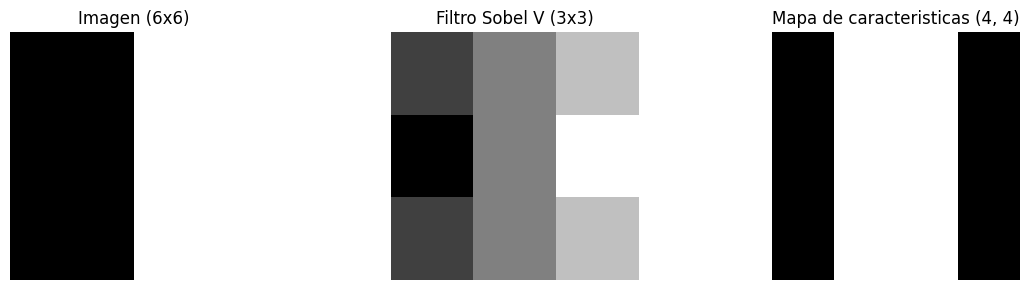

Valores del mapa de caracteristicas:
[[   0. 1020. 1020.    0.]
 [   0. 1020. 1020.    0.]
 [   0. 1020. 1020.    0.]
 [   0. 1020. 1020.    0.]]


In [2]:
def convolve2d(image, kernel):
    """Convolución 2D ingenua (sin padding, stride=1)."""
    h, w = image.shape
    k = kernel.shape[0]
    output = np.zeros((h - k + 1, w - k + 1))
    for i in range(h - k + 1):
        for j in range(w - k + 1):
            output[i, j] = np.sum(image[i:i+k, j:j+k] * kernel)
    return output

# Imagen sintética con un borde vertical claro
imagen = np.array([
    [0, 0, 0, 255, 255, 255],
    [0, 0, 0, 255, 255, 255],
    [0, 0, 0, 255, 255, 255],
    [0, 0, 0, 255, 255, 255],
    [0, 0, 0, 255, 255, 255],
    [0, 0, 0, 255, 255, 255],
], dtype=float)

# Filtro Sobel para detectar bordes verticales
kernel_sobel_v = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=float)

mapa_caract = convolve2d(imagen, kernel_sobel_v)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(imagen, cmap='gray'); axes[0].set_title('Imagen (6x6)')
axes[1].imshow(kernel_sobel_v, cmap='gray'); axes[1].set_title('Filtro Sobel V (3x3)')
axes[2].imshow(mapa_caract, cmap='gray'); axes[2].set_title(f'Mapa de caracteristicas {mapa_caract.shape}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

print('Valores del mapa de caracteristicas:')
print(mapa_caract)

**Observa:** el mapa de características tiene valores **altos** justo en la columna donde está el borde de la imagen, y **cero** en las zonas planas. El filtro "detecta" el patrón que codifica.

Una CNN aprenderá miles de filtros como este de forma automática durante el entrenamiento.

---

## Parte 2 — Cargar CIFAR-10 (dataset desde internet)

CIFAR-10 es un dataset clásico de **60.000 imágenes a color de 32×32 píxeles** en 10 categorías (avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco, camión).

Se descarga automáticamente desde los servidores de la Universidad de Toronto la primera vez que lo invocas:

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['avion', 'auto', 'pajaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camion']

print(f'X_train shape: {X_train.shape}')  # (50000, 32, 32, 3)
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'Numero de clases: {len(class_names)}')
print(f'Rango de pixeles: [{X_train.min()}, {X_train.max()}]')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape:  (10000, 32, 32, 3)
Numero de clases: 10
Rango de pixeles: [0, 255]


/Users/diegoramirez/Documents/USM/Redes Neuronales/00_Notebooks_Practica/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


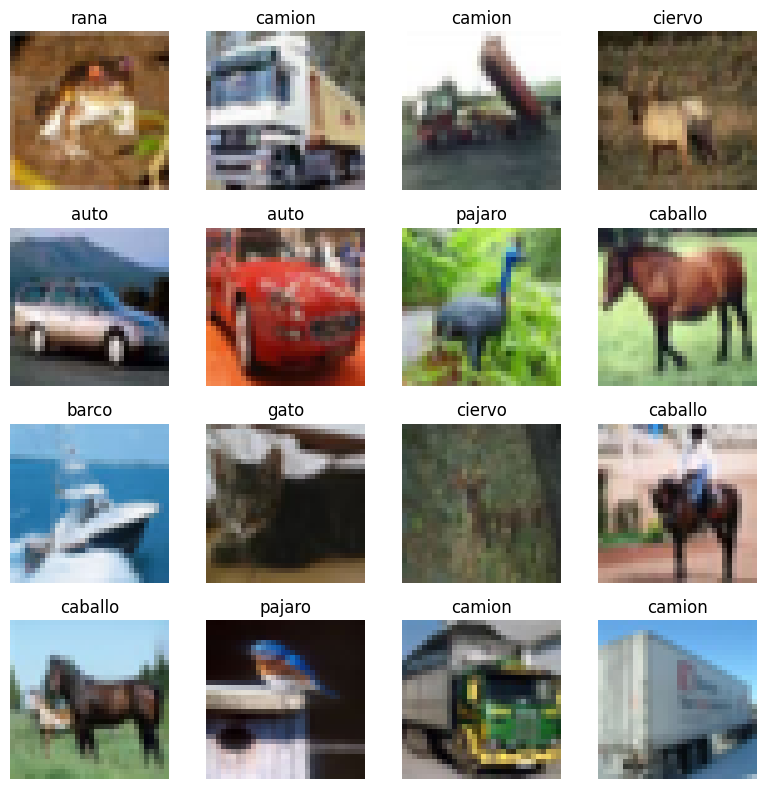

In [10]:
# Mostrar 16 imagenes de muestra
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(class_names[y_train[i][0]])
    ax.axis('off')
plt.tight_layout(); plt.show()

### Preprocesamiento

1. Normalizar píxeles a `[0, 1]` dividiendo por 255.
2. Convertir etiquetas a **one-hot encoding** (necesario para `categorical_crossentropy`).

In [13]:
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test,  num_classes=10)

print(f'y_train one-hot shape: {y_train_oh.shape}')
print(f'Primera etiqueta one-hot: {y_train_oh[0]} (clase: {class_names[y_train[0][0]]})')

y_train one-hot shape: (50000, 10)
Primera etiqueta one-hot: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.] (clase: rana)


---

## Parte 3 — Modelo baseline: red fully-connected (MLP)

Antes de usar una CNN, entrenemos una red **densa tradicional** para tener un punto de comparación. Esto demuestra por qué las CNN son necesarias para imágenes.

In [14]:
mlp = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),    # 3072 entradas
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10,  activation='softmax'),
], name='MLP_baseline')

mlp.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])
mlp.summary()

/Users/diegoramirez/Documents/USM/Redes Neuronales/00_Notebooks_Practica/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "MLP_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
hist_mlp = mlp.fit(X_train, y_train_oh,
                   epochs=8, batch_size=128,
                   validation_split=0.1, verbose=2)

test_loss, test_acc_mlp = mlp.evaluate(X_test, y_test_oh, verbose=0)
print(f'\nMLP - Test accuracy: {test_acc_mlp:.4f}')

Epoch 1/8
352/352 - 1s - 3ms/step - accuracy: 0.0976 - loss: 2.3027 - val_accuracy: 0.1064 - val_loss: 2.3025
Epoch 2/8
352/352 - 1s - 2ms/step - accuracy: 0.0954 - loss: 2.3027 - val_accuracy: 0.0986 - val_loss: 2.3026
Epoch 3/8
352/352 - 1s - 2ms/step - accuracy: 0.0968 - loss: 2.3027 - val_accuracy: 0.0986 - val_loss: 2.3026
Epoch 4/8
352/352 - 1s - 2ms/step - accuracy: 0.0971 - loss: 2.3027 - val_accuracy: 0.0986 - val_loss: 2.3026
Epoch 5/8
352/352 - 1s - 2ms/step - accuracy: 0.0970 - loss: 2.3027 - val_accuracy: 0.0986 - val_loss: 2.3026
Epoch 6/8
352/352 - 1s - 2ms/step - accuracy: 0.0969 - loss: 2.3027 - val_accuracy: 0.0986 - val_loss: 2.3026
Epoch 7/8
352/352 - 1s - 2ms/step - accuracy: 0.0969 - loss: 2.3027 - val_accuracy: 0.0986 - val_loss: 2.3026
Epoch 8/8
352/352 - 1s - 2ms/step - accuracy: 0.0969 - loss: 2.3027 - val_accuracy: 0.0986 - val_loss: 2.3026

MLP - Test accuracy: 0.1000


Un MLP típicamente alcanza ~45–50% de accuracy en CIFAR-10. **Mucho mejor que azar (10%)**, pero limitado: trata cada píxel de forma independiente y no aprovecha la estructura espacial. Veamos cómo lo mejora una CNN.

---

## Parte 4 — Construir una CNN paso a paso

Vamos a construir una CNN inspirada en la arquitectura **VGG en miniatura**: bloques de `Conv → Conv → MaxPool` que se hacen progresivamente más profundos.

**Patrón clave:**
1. Cada `Conv2D(N, 3x3)` aprende `N` filtros que detectan patrones locales.
2. `MaxPooling2D(2,2)` reduce la resolución espacial a la mitad.
3. A medida que la imagen se hace más pequeña, aumentamos el número de filtros (32 → 64 → 128).
4. `Flatten + Dense` realizan la clasificación final.

In [16]:
cnn = models.Sequential([
    # Bloque 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Bloque 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Bloque 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Clasificador
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
], name='CNN_VGG_mini')

cnn.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])
cnn.summary()

/Users/diegoramirez/Documents/USM/Redes Neuronales/00_Notebooks_Practica/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_VGG_mini"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,122 (3.11 MB)

 Trainable params: 814,122 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

**Pregunta de discusión:** compara el número de parámetros del MLP con el de la CNN. ¿Cuál tiene más? ¿Por qué la CNN puede tener menos parámetros y aún así rendir mejor?

---

## Parte 5 — Entrenamiento y curvas de aprendizaje

Usaremos `EarlyStopping` para frenar el entrenamiento si la pérdida de validación deja de mejorar.

In [17]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

hist_cnn = cnn.fit(X_train, y_train_oh,
                   epochs=15, batch_size=128,
                   validation_split=0.1,
                   callbacks=[early_stop],
                   verbose=2)

test_loss_cnn, test_acc_cnn = cnn.evaluate(X_test, y_test_oh, verbose=0)
print(f'\nCNN - Test accuracy: {test_acc_cnn:.4f}')

Epoch 1/15
352/352 - 25s - 71ms/step - accuracy: 0.0976 - loss: 2.3028 - val_accuracy: 0.0986 - val_loss: 2.3025
Epoch 2/15
352/352 - 25s - 71ms/step - accuracy: 0.0979 - loss: 2.3028 - val_accuracy: 0.1064 - val_loss: 2.3025
Epoch 3/15
352/352 - 25s - 71ms/step - accuracy: 0.0962 - loss: 2.3028 - val_accuracy: 0.1064 - val_loss: 2.3025
Epoch 4/15
352/352 - 24s - 68ms/step - accuracy: 0.0974 - loss: 2.3027 - val_accuracy: 0.1064 - val_loss: 2.3026

CNN - Test accuracy: 0.1000


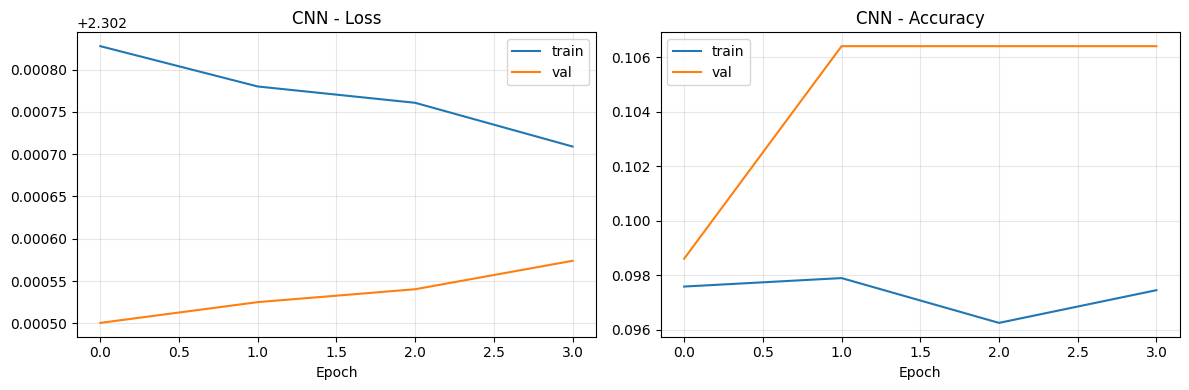

In [18]:
def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'], label='train')
    axes[0].plot(history.history['val_loss'], label='val')
    axes[0].set_title(f'{title} - Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history.history['accuracy'], label='train')
    axes[1].plot(history.history['val_accuracy'], label='val')
    axes[1].set_title(f'{title} - Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_history(hist_cnn, title='CNN')

**Interpretación de las curvas:**
- Si `train_loss` baja pero `val_loss` empieza a subir → **overfitting**.
- Si ambas suben o no bajan → **underfitting** (modelo muy simple, learning rate mal, datos pobres).
- Si ambas bajan en paralelo → buena generalización.

---

## Parte 6 — Evaluación: matriz de confusión y errores

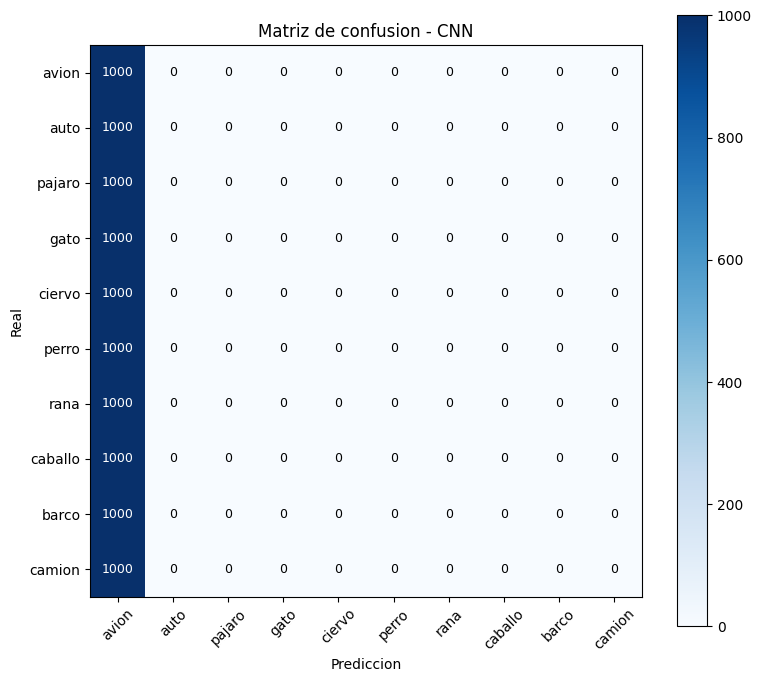

              precision    recall  f1-score   support

       avion      0.100     1.000     0.182      1000
        auto      0.000     0.000     0.000      1000
      pajaro      0.000     0.000     0.000      1000
        gato      0.000     0.000     0.000      1000
      ciervo      0.000     0.000     0.000      1000
       perro      0.000     0.000     0.000      1000
        rana      0.000     0.000     0.000      1000
     caballo      0.000     0.000     0.000      1000
       barco      0.000     0.000     0.000      1000
      camion      0.000     0.000     0.000      1000

    accuracy                          0.100     10000
   macro avg      0.010     0.100     0.018     10000
weighted avg      0.010     0.100     0.018     10000



/Users/diegoramirez/Documents/USM/Redes Neuronales/00_Notebooks_Practica/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/diegoramirez/Documents/USM/Redes Neuronales/00_Notebooks_Practica/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/diegoramirez/Documents/USM/Redes Neuronales/00_Notebooks_Practica/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = cnn.predict(X_test, verbose=0).argmax(axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_xticklabels(class_names, rotation=45)
ax.set_yticks(range(10)); ax.set_yticklabels(class_names)
ax.set_xlabel('Prediccion'); ax.set_ylabel('Real')
ax.set_title('Matriz de confusion - CNN')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=9)
plt.colorbar(im); plt.tight_layout(); plt.show()

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

Total de errores: 9000 de 10000


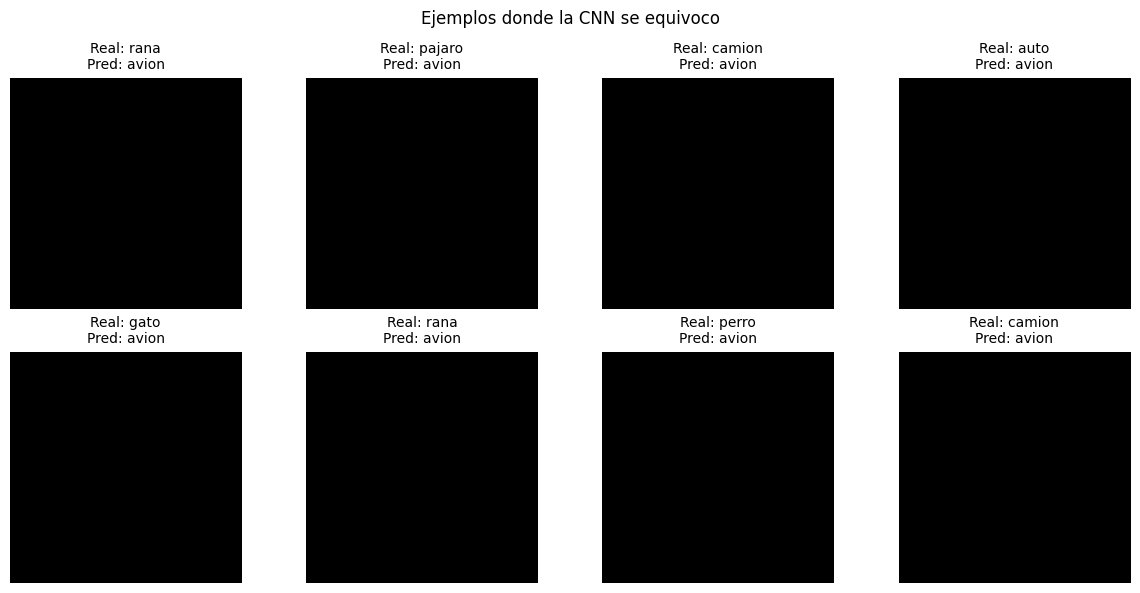

In [20]:
# Ver algunos ejemplos donde el modelo se equivoco
errores = np.where(y_pred != y_true)[0]
print(f'Total de errores: {len(errores)} de {len(y_true)}')

muestras = np.random.choice(errores, size=8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axes.flat, muestras):
    ax.imshow(X_test[idx])
    ax.set_title(f'Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}', fontsize=10)
    ax.axis('off')
plt.suptitle('Ejemplos donde la CNN se equivoco'); plt.tight_layout(); plt.show()

---

## Parte 7 — Data Augmentation

Generamos versiones "aumentadas" de cada imagen en tiempo de entrenamiento: rotaciones, flips, zooms… Esto multiplica artificialmente el dataset y mejora la generalización.

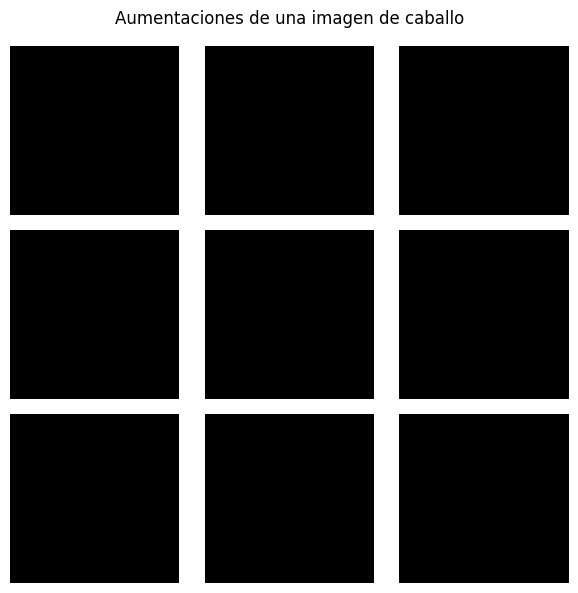

In [22]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='augmentation')

# Visualizar 9 versiones aumentadas de una misma imagen
img = X_train[7]
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for ax in axes.flat:
    aug = data_augmentation(tf.expand_dims(img, 0), training=True)[0].numpy()
    ax.imshow(np.clip(aug, 0, 1)); ax.axis('off')
plt.suptitle(f'Aumentaciones de una imagen de {class_names[y_train[7][0]]}')
plt.tight_layout(); plt.show()

Epoch 1/15
352/352 - 20s - 56ms/step - accuracy: 0.0981 - loss: 2.3029 - val_accuracy: 0.1064 - val_loss: 2.3025
Epoch 2/15
352/352 - 19s - 54ms/step - accuracy: 0.0964 - loss: 2.3028 - val_accuracy: 0.1064 - val_loss: 2.3025
Epoch 3/15
352/352 - 20s - 56ms/step - accuracy: 0.0950 - loss: 2.3028 - val_accuracy: 0.0986 - val_loss: 2.3026
Epoch 4/15
352/352 - 20s - 57ms/step - accuracy: 0.0970 - loss: 2.3027 - val_accuracy: 0.0986 - val_loss: 2.3026
Epoch 5/15
352/352 - 19s - 54ms/step - accuracy: 0.0975 - loss: 2.3027 - val_accuracy: 0.0986 - val_loss: 2.3026
Epoch 6/15
352/352 - 19s - 53ms/step - accuracy: 0.0964 - loss: 2.3027 - val_accuracy: 0.1064 - val_loss: 2.3026

CNN + Augmentation - Test accuracy: 0.1000


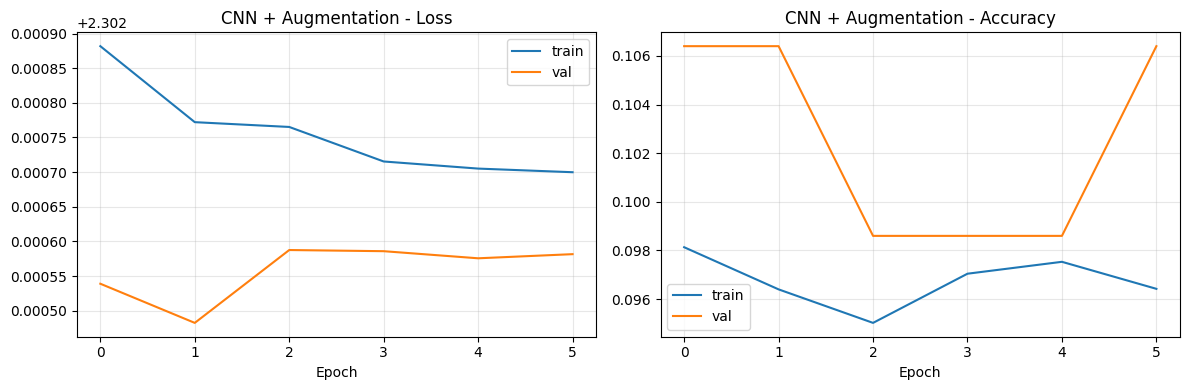

In [23]:
# CNN con data augmentation integrada
cnn_aug = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
], name='CNN_con_augmentation')

cnn_aug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

hist_aug = cnn_aug.fit(X_train, y_train_oh,
                       epochs=15, batch_size=128,
                       validation_split=0.1,
                       callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)],
                       verbose=2)

_, test_acc_aug = cnn_aug.evaluate(X_test, y_test_oh, verbose=0)
print(f'\nCNN + Augmentation - Test accuracy: {test_acc_aug:.4f}')
plot_history(hist_aug, title='CNN + Augmentation')

---

## Parte 8 — Transfer Learning con MobileNetV2

En lugar de entrenar una CNN desde cero, partimos de **MobileNetV2** preentrenada en ImageNet (1.4 millones de imágenes). Solo entrenamos las capas finales para nuestra tarea.

*MobileNetV2 espera imágenes de al menos 96×96, así que las escalamos.*

In [24]:
# Reescalar imagenes a 96x96 para que MobileNetV2 las acepte
IMG_SIZE = 96
X_train_resized = tf.image.resize(X_train, (IMG_SIZE, IMG_SIZE)).numpy()
X_test_resized  = tf.image.resize(X_test,  (IMG_SIZE, IMG_SIZE)).numpy()
print(f'Nuevo shape: {X_train_resized.shape}')

Nuevo shape: (50000, 96, 96, 3)


In [25]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,            # quitamos el clasificador de ImageNet
    weights='imagenet'
)
base_model.trainable = False       # congelamos los pesos preentrenados

model_tl = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Rescaling(2.0, offset=-1.0),  # MobileNetV2 espera entrada en [-1, 1]
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax'),
], name='TransferLearning_MobileNetV2')

model_tl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "TransferLearning_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
hist_tl = model_tl.fit(X_train_resized, y_train_oh,
                       epochs=5, batch_size=128,
                       validation_split=0.1, verbose=2)

_, test_acc_tl = model_tl.evaluate(X_test_resized, y_test_oh, verbose=0)
print(f'\nTransfer Learning - Test accuracy: {test_acc_tl:.4f}')

Epoch 1/5
352/352 - 30s - 86ms/step - accuracy: 0.1022 - loss: 2.4397 - val_accuracy: 0.1064 - val_loss: 2.3178
Epoch 2/5
352/352 - 29s - 84ms/step - accuracy: 0.0988 - loss: 2.3469 - val_accuracy: 0.1064 - val_loss: 2.3199
Epoch 3/5
352/352 - 27s - 77ms/step - accuracy: 0.0956 - loss: 2.3332 - val_accuracy: 0.1064 - val_loss: 2.3197
Epoch 4/5
352/352 - 28s - 80ms/step - accuracy: 0.0991 - loss: 2.3296 - val_accuracy: 0.1064 - val_loss: 2.3179
Epoch 5/5
352/352 - 27s - 77ms/step - accuracy: 0.1001 - loss: 2.3282 - val_accuracy: 0.1064 - val_loss: 2.3203

Transfer Learning - Test accuracy: 0.1000


### Comparación final de los 4 modelos

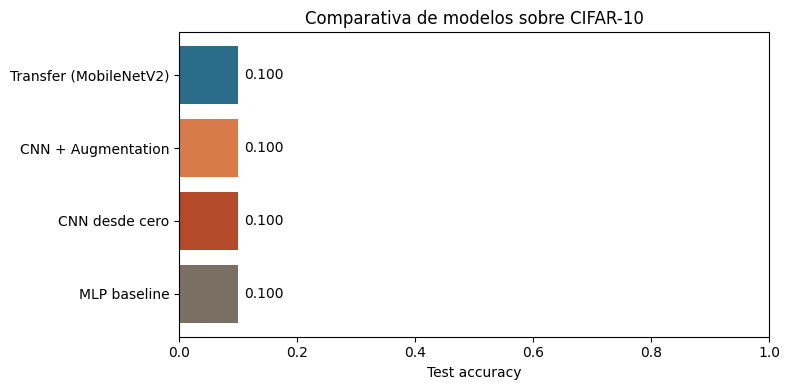

  MLP baseline                  : 0.1000
  CNN desde cero                : 0.1000
  CNN + Augmentation            : 0.1000
  Transfer (MobileNetV2)        : 0.1000


In [27]:
resultados = {
    'MLP baseline':          test_acc_mlp,
    'CNN desde cero':        test_acc_cnn,
    'CNN + Augmentation':    test_acc_aug,
    'Transfer (MobileNetV2)': test_acc_tl,
}

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(list(resultados.keys()), list(resultados.values()), color=['#7a6f63', '#b34a2a', '#d97a4a', '#2a6c8a'])
for i, v in enumerate(resultados.values()):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center')
ax.set_xlim(0, 1); ax.set_xlabel('Test accuracy'); ax.set_title('Comparativa de modelos sobre CIFAR-10')
plt.tight_layout(); plt.show()

for nombre, acc in resultados.items():
    print(f'  {nombre:30s}: {acc:.4f}')

---

# Parte 9 — EJERCICIOS PRÁCTICOS

Resuelve los siguientes ejercicios en celdas nuevas. Documenta tus respuestas con celdas de markdown explicando qué observas.

### Ejercicio 1 — Filtros hechos a mano (10 pts)

Modifica la función `convolve2d` de la Parte 1 para aplicarla a una imagen real de CIFAR-10 (puedes promediar los 3 canales para tener una imagen en escala de grises).

Aplica al menos **tres filtros distintos** y muestra los mapas de características resultantes:
1. Filtro Sobel horizontal `[[-1,-2,-1],[0,0,0],[1,2,1]]`.
2. Filtro de detección de esquinas / Laplaciano `[[0,-1,0],[-1,4,-1],[0,-1,0]]`.
3. Un filtro **inventado por ti**. Explica qué crees que detecta.

**Entrega:** las 3 visualizaciones + 2 párrafos de discusión.

In [ ]:
# Tu solucion aqui


### Ejercicio 2 — Análisis de arquitectura (15 pts)

Toma la `cnn` de la Parte 4 y crea **dos variantes**:

- **Variante A — "superficial":** elimina el Bloque 3 (capas Conv 128). Mantén el resto igual.
- **Variante B — "sin Dropout":** la arquitectura original pero sin ninguna capa `Dropout`.

Entrena ambas con los mismos hiperparámetros (8 epochs, batch 128). Compara:

| Modelo | #Params | Train acc | Val acc | Test acc |
|--------|---------|-----------|---------|----------|

Responde:
1. ¿Cuál sobreajusta más? ¿Cómo lo identificas en las curvas?
2. ¿Cuál es la importancia del Dropout?
3. ¿La red más profunda *siempre* es mejor? ¿Por qué sí o no?

In [ ]:
# Tu solucion aqui


### Ejercicio 3 — Hiperparámetros (10 pts)

Sobre la CNN de la Parte 4, experimenta con **al menos** dos de las siguientes modificaciones (una variable a la vez) y reporta el efecto en test accuracy:

- Cambiar el `optimizer`: `'sgd'` con `momentum=0.9` vs. `'adam'`.
- Cambiar `batch_size` a 32 y a 256.
- Cambiar el tamaño del kernel: usar `5×5` en lugar de `3×3` en el primer bloque.
- Reemplazar `MaxPooling2D` por `AveragePooling2D`.

Resume tus hallazgos en una tabla.

In [ ]:
# Tu solucion aqui


### Ejercicio 4 — Visualizar filtros aprendidos (10 pts)

Después de entrenar la CNN, extrae los pesos de la **primera capa convolucional** y visualízalos como pequeñas imágenes 3×3.

Pistas:
```python
W, b = cnn.layers[0].get_weights()   # W shape: (3, 3, 3, 32)
# Para cada uno de los 32 filtros, promedia los 3 canales y muestralo.
```

Responde: ¿logras identificar algún filtro que parezca detectar bordes, colores específicos o texturas?

In [ ]:
# Tu solucion aqui


---

# Parte 10 — PROYECTO FINAL (entregable, 55 pts)

## Reto: elige tu propio dataset y resuelve un problema de clasificación de imágenes con CNN.

### Datasets sugeridos (todos descargables desde internet)

| Dataset | Fuente | Clases | Dificultad |
|---------|--------|--------|------------|
| **Fashion-MNIST** | `tf.keras.datasets.fashion_mnist` | 10 | Fácil |
| **Cats vs Dogs** | `tensorflow_datasets.load('cats_vs_dogs')` | 2 | Media |
| **Rock-Paper-Scissors** | `tensorflow_datasets.load('rock_paper_scissors')` | 3 | Fácil |
| **Flowers (102 categorías)** | Oxford Flowers 102 (TFDS: `oxford_flowers102`) | 102 | Alta |
| **Intel Image Classification** | [Kaggle](https://www.kaggle.com/puneet6060/intel-image-classification) | 6 (paisajes) | Media |
| **Chest X-Ray Pneumonia** | [Kaggle](https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia) | 2 | Media-alta |
| **Food-101** | [Kaggle](https://www.kaggle.com/dansbecker/food-101) o TFDS | 101 | Alta |

> También puedes proponer **tu propio dataset** (debe tener mínimo 2 clases y al menos ~1.000 imágenes en total). Anúnciaselo al docente.

### Requisitos mínimos del informe

Tu entrega (este notebook completado) debe incluir:

1. **Introducción (5 pts).** ¿Qué dataset elegiste y por qué? ¿Qué problema real resuelve?
2. **Exploración de datos (5 pts).** Tamaño del dataset, dimensiones de las imágenes, distribución de clases (gráfico de barras), 9 muestras visualizadas.
3. **Preprocesamiento (5 pts).** División train / val / test (80/10/10 si no viene partido), normalización, one-hot.
4. **Modelo CNN propio (15 pts).** Justifica las decisiones de arquitectura. **Resumen** y diagrama del modelo.
5. **Entrenamiento (10 pts).** Curvas de loss y accuracy, uso de `EarlyStopping` y/o `ReduceLROnPlateau`. Argumenta los hiperparámetros elegidos.
6. **Evaluación (10 pts).** Test accuracy, matriz de confusión, precision/recall por clase y al menos 6 ejemplos de errores con análisis cualitativo.
7. **Mejora (5 pts).** Aplica **una** técnica adicional: data augmentation, transfer learning (VGG16/ResNet50/MobileNetV2/EfficientNet) o batch normalization. Reporta la mejora cuantitativa.
8. **Conclusiones (5 pts).** ¿Qué aprendiste? ¿Qué harías diferente con más tiempo / más datos / más cómputo? ¿Para qué aplicación real serviría tu modelo?

### Reglas de entrega

- Trabajo **individual o en parejas** (a definir por el docente).
- Entrega: el archivo `.ipynb` con todas las celdas ejecutadas + un PDF exportado del notebook.
- Nombre del archivo: `Lab10_CNN_<apellido1>_<apellido2>.ipynb`.
- Fecha de entrega: definida en aula.

### Rúbrica de evaluación (sobre 100 pts)

| Sección | Puntos |
|---------|--------|
| Ejercicios 1–4 (Parte 9) | 45 |
| Proyecto final (Parte 10) | 55 |
| **Total** | **100** |

**Puntos extra (+10):**
- (+5) Aplicar Grad-CAM u otra técnica de interpretabilidad sobre 3 imágenes.
- (+5) Comparar dos arquitecturas de transfer learning distintas (ej: VGG16 vs EfficientNetB0).

---

## Recursos de apoyo

- Documentación oficial: <https://www.tensorflow.org/tutorials/images/cnn>
- TensorFlow Datasets: <https://www.tensorflow.org/datasets/catalog/overview>
- Kaggle (datasets y kernels): <https://www.kaggle.com/datasets>
- Cómo escribir un buen notebook: usa celdas markdown para explicar **el porqué**, no solo el cómo.

## Tips para no morir en el intento

1. Usa **Google Colab con GPU** si no tienes tarjeta gráfica local.
2. Empieza con pocas epochs (3-5) para verificar que el pipeline funciona antes de entrenar 50 epochs.
3. Guarda checkpoints con `ModelCheckpoint` para no perder el modelo entrenado.
4. Si un modelo no aprende (accuracy ≈ 1/N de las clases), revisa: normalización, pérdida correcta para tu tipo de etiquetas, y learning rate.
5. Documenta tus decisiones a medida que las tomas — no al final.

---

*¡Suerte y a entrenar redes!*